In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

import numpy as np
import matplotlib.pyplot as plt

def gaussian(mu, sigma, n, rng):
    return rng.normal(mu, sigma, n)

def gaussian_2d(mu, Sigma, n, rng):
    S11 = Sigma[0, 0]
    S12 = Sigma[0, 1]
    S22 = Sigma[1, 1]

    x1 = gaussian(mu[0], np.sqrt(S11), n, rng)

    z = gaussian(0, 1, n, rng)
    cond_mean = mu[1] + (S12 / S11) * (x1 - mu[0])
    cond_var = S22 - S12 ** 2 / S11
    x2 = cond_mean + np.sqrt(cond_var) * z

    return np.column_stack((x1, x2))

In [8]:
rng = np.random.default_rng(42)
N = 10000

mu1 = np.array([0.0, 0.0])
mu2 = np.array([4.0, 4.0])
mu3 = np.array([0.0, 6.0])

# simplest case first: sigma^2 I, same for all classes
Sigma1 = np.array([[2.0, 0.0], [0.0, 2.0]])
Sigma2 = np.array([[2.0, 0.0], [0.0, 2.0]])
Sigma3 = np.array([[2.0, 0.0], [0.0, 2.0]])

X1 = gaussian_2d(mu1, Sigma1, N, rng)
X2 = gaussian_2d(mu2, Sigma2, N, rng)
X3 = gaussian_2d(mu3, Sigma3, N, rng)

print(X1.shape, X2.shape, X3.shape)

(10000, 2) (10000, 2) (10000, 2)


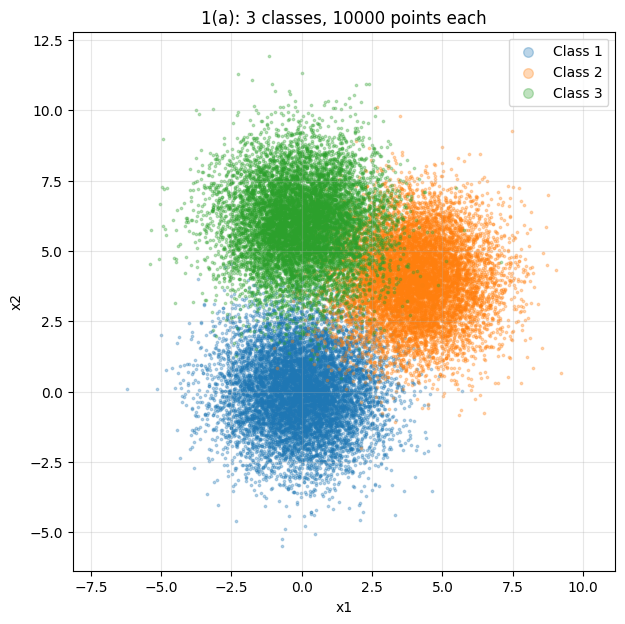

In [9]:
plt.figure(figsize=(7, 7))
plt.scatter(X1[:, 0], X1[:, 1], s=3, alpha=0.3, label="Class 1")
plt.scatter(X2[:, 0], X2[:, 1], s=3, alpha=0.3, label="Class 2")
plt.scatter(X3[:, 0], X3[:, 1], s=3, alpha=0.3, label="Class 3")
plt.xlabel("x1"); plt.ylabel("x2")
plt.title("1(a): 3 classes, 10000 points each")
plt.axis("equal"); plt.grid(alpha=0.3); plt.legend(markerscale=4)
plt.show()

In [11]:
# the three covariance types

#1)b
Sigma_iso  = np.array([[2.0, 0.0], [0.0, 2.0]])
Sigma_diag = np.array([[3.0, 0.0], [0.0, 1.0]])
Sigma_full = np.array([[3.0, 1.5], [1.5, 2.0]])

# (a) sigma^2 I, same for all 3 classes
A1 = gaussian_2d(mu1, Sigma_iso, N, rng)
A2 = gaussian_2d(mu2, Sigma_iso, N, rng)
A3 = gaussian_2d(mu3, Sigma_iso, N, rng)

# (b) diagonal, same for all 3 classes
B1 = gaussian_2d(mu1, Sigma_diag, N, rng)
B2 = gaussian_2d(mu2, Sigma_diag, N, rng)
B3 = gaussian_2d(mu3, Sigma_diag, N, rng)

# (c) full, same for all 3 classes
C1 = gaussian_2d(mu1, Sigma_full, N, rng)
C2 = gaussian_2d(mu2, Sigma_full, N, rng)
C3 = gaussian_2d(mu3, Sigma_full, N, rng)

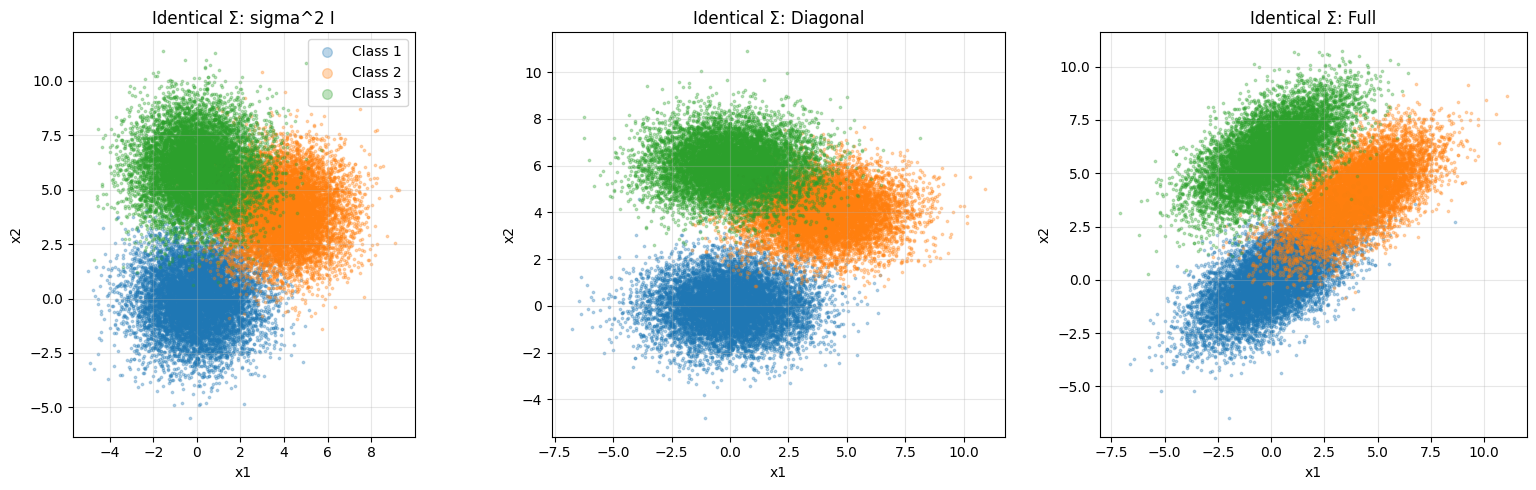

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sets = [("sigma^2 I", A1, A2, A3),
        ("Diagonal",  B1, B2, B3),
        ("Full",      C1, C2, C3)]

for ax, (title, P1, P2, P3) in zip(axes, sets):
    ax.scatter(P1[:, 0], P1[:, 1], s=3, alpha=0.3, label="Class 1")
    ax.scatter(P2[:, 0], P2[:, 1], s=3, alpha=0.3, label="Class 2")
    ax.scatter(P3[:, 0], P3[:, 1], s=3, alpha=0.3, label="Class 3")
    ax.set_title(f"Identical Σ: {title}")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_aspect("equal"); ax.grid(alpha=0.3)

axes[0].legend(markerscale=4)
plt.tight_layout()
plt.show()

In [13]:
# (a) sigma^2 I, different per class

 # 1 c ) 
Sigma1_iso = np.array([[1.0, 0.0], [0.0, 1.0]])
Sigma2_iso = np.array([[3.0, 0.0], [0.0, 3.0]])
Sigma3_iso = np.array([[2.0, 0.0], [0.0, 2.0]])

D1 = gaussian_2d(mu1, Sigma1_iso, N, rng)
D2 = gaussian_2d(mu2, Sigma2_iso, N, rng)
D3 = gaussian_2d(mu3, Sigma3_iso, N, rng)

# (b) diagonal, different per class
Sigma1_diag = np.array([[1.0, 0.0], [0.0, 3.0]])
Sigma2_diag = np.array([[4.0, 0.0], [0.0, 1.0]])
Sigma3_diag = np.array([[2.0, 0.0], [0.0, 2.0]])

E1 = gaussian_2d(mu1, Sigma1_diag, N, rng)
E2 = gaussian_2d(mu2, Sigma2_diag, N, rng)
E3 = gaussian_2d(mu3, Sigma3_diag, N, rng)

# (c) full, different per class
Sigma1_full = np.array([[2.0, 1.2], [1.2, 2.0]])
Sigma2_full = np.array([[3.0, -1.5], [-1.5, 2.0]])
Sigma3_full = np.array([[1.5, 0.5], [0.5, 3.0]])

F1 = gaussian_2d(mu1, Sigma1_full, N, rng)
F2 = gaussian_2d(mu2, Sigma2_full, N, rng)
F3 = gaussian_2d(mu3, Sigma3_full, N, rng)

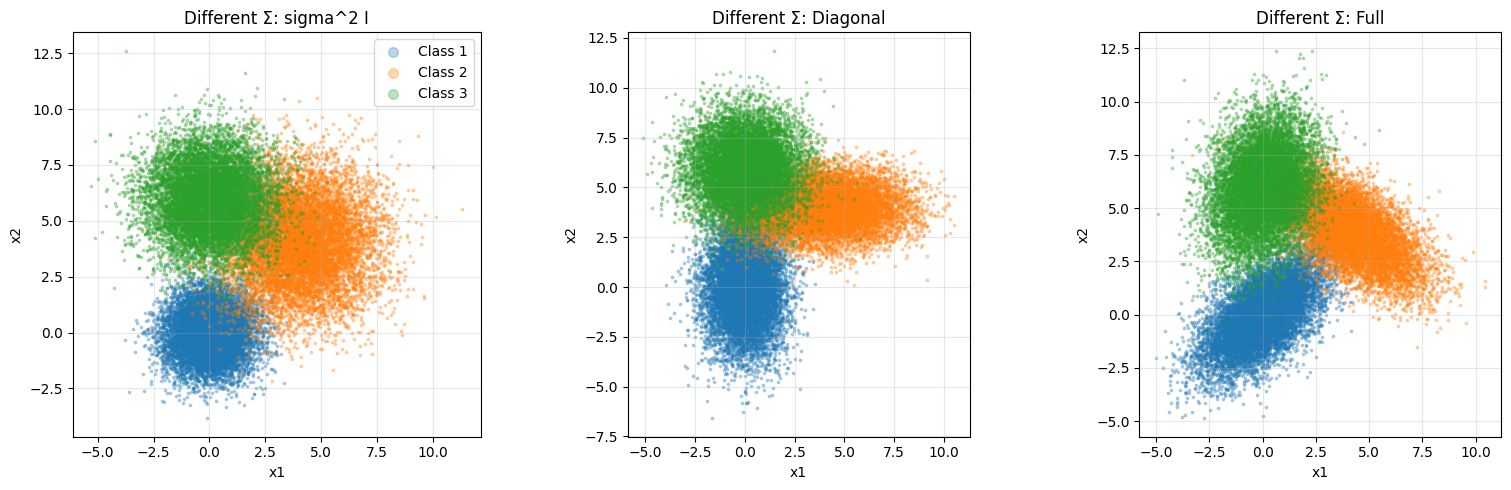

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sets = [("sigma^2 I", D1, D2, D3),
        ("Diagonal",  E1, E2, E3),
        ("Full",      F1, F2, F3)]

for ax, (title, P1, P2, P3) in zip(axes, sets):
    ax.scatter(P1[:, 0], P1[:, 1], s=3, alpha=0.3, label="Class 1")
    ax.scatter(P2[:, 0], P2[:, 1], s=3, alpha=0.3, label="Class 2")
    ax.scatter(P3[:, 0], P3[:, 1], s=3, alpha=0.3, label="Class 3")
    ax.set_title(f"Different Σ: {title}")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_aspect("equal"); ax.grid(alpha=0.3)

axes[0].legend(markerscale=4)
plt.tight_layout()
plt.show()

In [15]:
# split: 80% train (8000), 20% test (2000) per class

# 1d)

F1_train, F1_test = F1[:8000], F1[8000:]
F2_train, F2_test = F2[:8000], F2[8000:]
F3_train, F3_test = F3[:8000], F3[8000:]

print(F1_train.shape, F1_test.shape)

(8000, 2) (2000, 2)


In [16]:
n = len(F1_train)

# mean: (1/n) * sum of x
mu1_hat = np.array([np.sum(F1_train[:, 0]) / n,
                    np.sum(F1_train[:, 1]) / n])

# offsets from the mean
d1 = F1_train[:, 0] - mu1_hat[0]
d2 = F1_train[:, 1] - mu1_hat[1]

# covariance: (1/n) * sum of (x-mu)(x-mu)^T, one entry at a time
S11 = np.sum(d1 * d1) / n
S12 = np.sum(d1 * d2) / n
S22 = np.sum(d2 * d2) / n
Sigma1_hat = np.array([[S11, S12],
                       [S12, S22]])

print("true mu   :", mu1)
print("est  mu   :", mu1_hat)
print("true Sigma:\n", Sigma1_full)
print("est  Sigma:\n", Sigma1_hat)

true mu   : [0. 0.]
est  mu   : [-0.00850879 -0.00194617]
true Sigma:
 [[2.  1.2]
 [1.2 2. ]]
est  Sigma:
 [[2.04207173 1.20592636]
 [1.20592636 1.99736471]]


In [17]:
def mle(X):
    n = len(X)
    mu_hat = np.array([np.sum(X[:, 0]) / n,
                       np.sum(X[:, 1]) / n])
    d1 = X[:, 0] - mu_hat[0]
    d2 = X[:, 1] - mu_hat[1]
    S11 = np.sum(d1 * d1) / n
    S12 = np.sum(d1 * d2) / n
    S22 = np.sum(d2 * d2) / n
    return mu_hat, np.array([[S11, S12], [S12, S22]])

mu2_hat, Sigma2_hat = mle(F2_train)
mu3_hat, Sigma3_hat = mle(F3_train)

for i, (m, S) in enumerate([(mu1_hat, Sigma1_hat),
                            (mu2_hat, Sigma2_hat),
                            (mu3_hat, Sigma3_hat)], start=1):
    print(f"Class {i}  mu_hat = {np.round(m, 3)}")
    print(np.round(S, 3))

Class 1  mu_hat = [-0.009 -0.002]
[[2.042 1.206]
 [1.206 1.997]]
Class 2  mu_hat = [3.978 4.024]
[[ 3.035 -1.534]
 [-1.534  2.009]]
Class 3  mu_hat = [-0.012  5.983]
[[1.49  0.489]
 [0.489 2.952]]


In [18]:
#)1d

datasets = {
    "Same, sigma^2 I": [A1, A2, A3],
    "Same, diagonal":  [B1, B2, B3],
    "Same, full":      [C1, C2, C3],
    "Diff, sigma^2 I": [D1, D2, D3],
    "Diff, diagonal":  [E1, E2, E3],
    "Diff, full":      [F1, F2, F3],
}

train, test, params = {}, {}, {}

for name, classes in datasets.items():
    train[name]  = [X[:8000] for X in classes]
    test[name]   = [X[8000:] for X in classes]
    params[name] = [mle(X) for X in train[name]]

    print("\n" + name)
    for i in range(3):
        mu_hat, Sigma_hat = params[name][i]
        print(f"  Class {i+1}  mu_hat = {np.round(mu_hat, 3)}")
        print(np.round(Sigma_hat, 3))


Same, sigma^2 I
  Class 1  mu_hat = [ 0.014 -0.012]
[[ 2.029 -0.004]
 [-0.004  2.006]]
  Class 2  mu_hat = [3.995 3.965]
[[2.061e+00 2.000e-03]
 [2.000e-03 2.014e+00]]
  Class 3  mu_hat = [-0.017  6.   ]
[[ 2.009 -0.004]
 [-0.004  2.015]]

Same, diagonal
  Class 1  mu_hat = [-0.003  0.003]
[[3.004 0.007]
 [0.007 1.023]]
  Class 2  mu_hat = [3.982 4.   ]
[[3.021 0.023]
 [0.023 0.985]]
  Class 3  mu_hat = [0.017 6.027]
[[ 2.962 -0.005]
 [-0.005  0.999]]

Same, full
  Class 1  mu_hat = [-0.005 -0.004]
[[3.066 1.523]
 [1.523 1.978]]
  Class 2  mu_hat = [4.004 4.004]
[[2.95  1.468]
 [1.468 1.962]]
  Class 3  mu_hat = [-0.015  6.001]
[[3.019 1.509]
 [1.509 1.976]]

Diff, sigma^2 I
  Class 1  mu_hat = [ 0.005 -0.001]
[[0.999 0.017]
 [0.017 1.028]]
  Class 2  mu_hat = [3.992 4.037]
[[3.004 0.08 ]
 [0.08  3.045]]
  Class 3  mu_hat = [-0.006  5.991]
[[ 1.971 -0.013]
 [-0.013  1.985]]

Diff, diagonal
  Class 1  mu_hat = [ 0.003 -0.012]
[[1.031 0.004]
 [0.004 2.947]]
  Class 2  mu_hat = [3.992 4.

In [19]:
def g(X, mu_hat, Sigma_hat):
    a = Sigma_hat[0, 0]
    b = Sigma_hat[0, 1]
    d = Sigma_hat[1, 1]

    det = a * d - b * b
    inv11 = d / det
    inv12 = -b / det
    inv22 = a / det

    u = X[:, 0] - mu_hat[0]
    v = X[:, 1] - mu_hat[1]

    maha2 = inv11 * u * u + 2 * inv12 * u * v + inv22 * v * v

    return -0.5 * maha2 - 0.5 * np.log(det)

In [20]:
predictions = {}   # predictions[name] = (X_test_all, y_true, y_pred)

for name in datasets:
    # stack the three test sets into one, with true labels 0,1,2
    X_test = np.vstack(test[name])
    y_true = np.concatenate([np.full(2000, 0),
                             np.full(2000, 1),
                             np.full(2000, 2)])

    # score every test point under each class model
    g1 = g(X_test, *params[name][0])
    g2 = g(X_test, *params[name][1])
    g3 = g(X_test, *params[name][2])

    # pick the class with the largest g
    scores = np.column_stack((g1, g2, g3))
    y_pred = np.argmax(scores, axis=1)

    predictions[name] = (X_test, y_true, y_pred)

    correct = np.sum(y_pred == y_true)
    print(f"{name:18s} correct: {correct} / {len(y_true)}")

Same, sigma^2 I    correct: 5635 / 6000
Same, diagonal     correct: 5676 / 6000
Same, full         correct: 5663 / 6000
Diff, sigma^2 I    correct: 5654 / 6000
Diff, diagonal     correct: 5574 / 6000
Diff, full         correct: 5619 / 6000


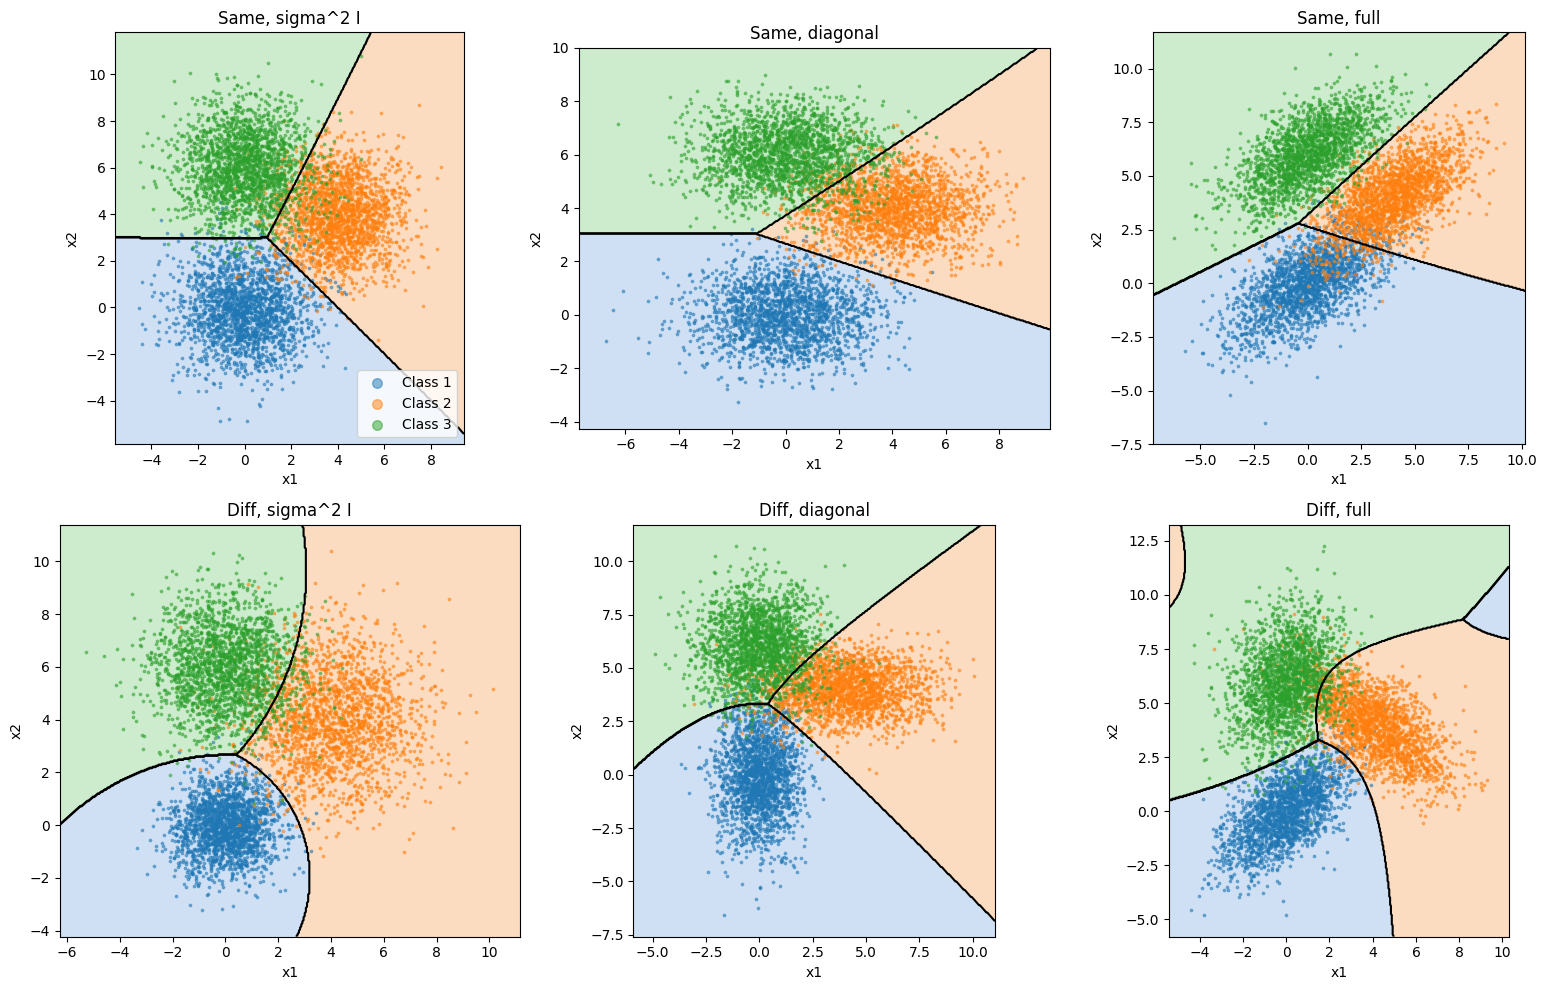

In [21]:
# 1 f 

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
region_colors = plt.matplotlib.colors.ListedColormap(["#cfe0f5", "#fbdcc0", "#cdeccd"])
point_colors = ["tab:blue", "tab:orange", "tab:green"]

for ax, name in zip(axes.ravel(), datasets):
    X_test, y_true, y_pred = predictions[name]

    # grid covering the test data
    gx = np.linspace(X_test[:, 0].min() - 1, X_test[:, 0].max() + 1, 400)
    gy = np.linspace(X_test[:, 1].min() - 1, X_test[:, 1].max() + 1, 400)
    GX, GY = np.meshgrid(gx, gy)
    grid = np.column_stack((GX.ravel(), GY.ravel()))

    # classify every grid point with the same rule
    s1 = g(grid, *params[name][0])
    s2 = g(grid, *params[name][1])
    s3 = g(grid, *params[name][2])
    Z = np.argmax(np.column_stack((s1, s2, s3)), axis=1).reshape(GX.shape)

    # decision regions and boundaries
    ax.contourf(GX, GY, Z, levels=[-0.5, 0.5, 1.5, 2.5], cmap=region_colors)
    ax.contour(GX, GY, Z, levels=[0.5, 1.5], colors="black", linewidths=1.5)

    # test data on top
    for c in range(3):
        pts = X_test[y_true == c]
        ax.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.5,
                   color=point_colors[c], label=f"Class {c+1}")

    ax.set_title(name)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_aspect("equal")

axes[0, 0].legend(markerscale=4, loc="lower right")
plt.tight_layout()
plt.show()

In [22]:
# 1 g

for name in datasets:
    X_test, y_true, y_pred = predictions[name]

    cm = np.zeros((3, 3), dtype=int)
    for i in range(3):
        for j in range(3):
            cm[i, j] = np.sum((y_true == i) & (y_pred == j))

    print("\n" + name)
    print("           Pred 1   Pred 2   Pred 3")
    for i in range(3):
        print(f"True {i+1}   {cm[i,0]:7d}  {cm[i,1]:7d}  {cm[i,2]:7d}")


Same, sigma^2 I
           Pred 1   Pred 2   Pred 3
True 1      1928       37       35
True 2        43     1857      100
True 3        26      124     1850

Same, diagonal
           Pred 1   Pred 2   Pred 3
True 1      1974       24        2
True 2        17     1840      143
True 3         0      138     1862

Same, full
           Pred 1   Pred 2   Pred 3
True 1      1868      127        5
True 2       142     1823       35
True 3         1       27     1972

Diff, sigma^2 I
           Pred 1   Pred 2   Pred 3
True 1      1981       12        7
True 2        31     1816      153
True 3        10      133     1857

Diff, diagonal
           Pred 1   Pred 2   Pred 3
True 1      1935       25       40
True 2        42     1797      161
True 3        38      120     1842

Diff, full
           Pred 1   Pred 2   Pred 3
True 1      1944       30       26
True 2        26     1811      163
True 3        36      100     1864


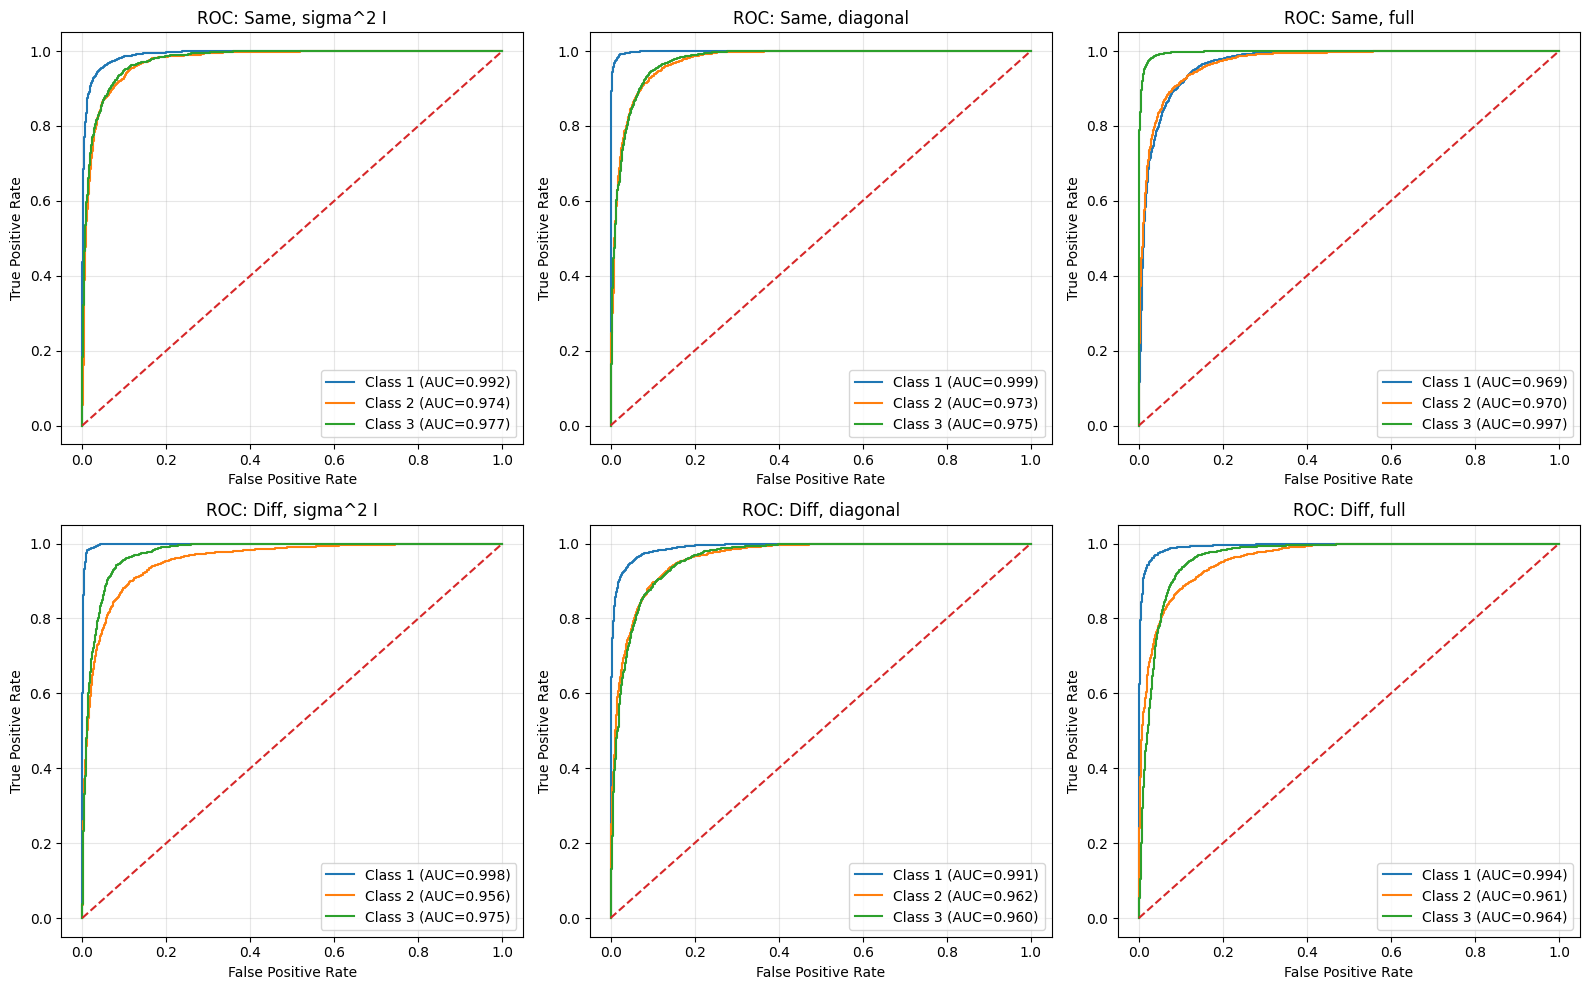

In [23]:
# ROC curves: one-vs-rest for each class

from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, name in zip(axes.ravel(), datasets):
    X_test, y_true, y_pred = predictions[name]

    # Get the same continuous scores used for classification
    g1 = g(X_test, *params[name][0])
    g2 = g(X_test, *params[name][1])
    g3 = g(X_test, *params[name][2])
    scores = np.column_stack((g1, g2, g3))

    # One-vs-rest ROC for each class
    for c in range(3):
        y_binary = (y_true == c).astype(int)
        fpr, tpr, _ = roc_curve(y_binary, scores[:, c])
        ax.plot(fpr, tpr, label=f"Class {c+1} (AUC={auc(fpr, tpr):.3f})")

    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(f"ROC: {name}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# part 2 

In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt

print("Notebook is running in:", os.getcwd())
print("Text files in this folder:", [f for f in os.listdir(".") if f.endswith(".txt")])

Notebook is running in: C:\Users\KUZHALAMANI\MY JUPYTER NOTEBOOK
Text files in this folder: ['dev.txt', 'trian.txt']


In [27]:
DATA_DIR   = "."            # or r"C:\Users\<you>\<folder with the files>"
TRAIN_FILE = "trian.txt"    # use the exact name you saw in the listing (maybe "train.txt")
DEV_FILE   = "dev.txt"

train_raw = np.loadtxt(os.path.join(DATA_DIR, TRAIN_FILE), delimiter=",")
dev_raw   = np.loadtxt(os.path.join(DATA_DIR, DEV_FILE),   delimiter=",")

data = np.vstack((train_raw, dev_raw))   # pool both files
X = data[:, :2]
y = data[:, 2].astype(int)

print("total points:", len(data))
for c in (1, 2, 3):
    print("class", c, ":", np.sum(y == c))

total points: 1350
class 1 : 450
class 2 : 450
class 3 : 450


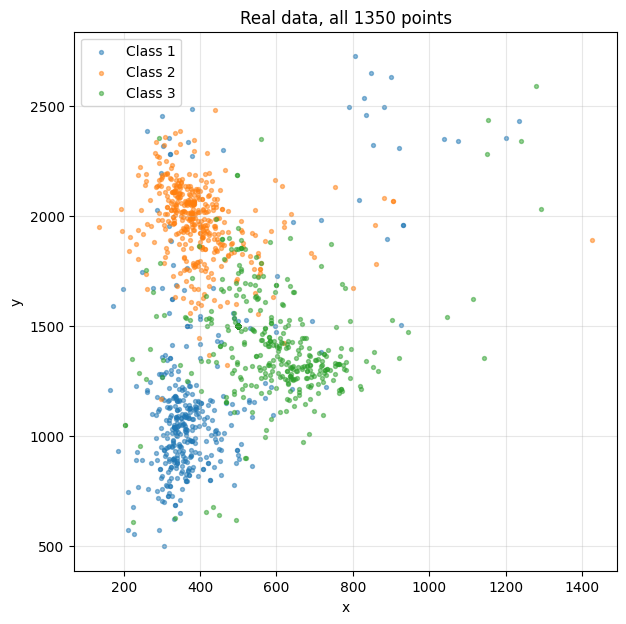

In [28]:
colors = {1: "tab:blue", 2: "tab:orange", 3: "tab:green"}

plt.figure(figsize=(7, 7))
for c in (1, 2, 3):
    pts = X[y == c]
    plt.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.5, color=colors[c], label=f"Class {c}")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Real data, all 1350 points")
plt.grid(alpha=0.3); plt.legend()
plt.show()

In [29]:
rng = np.random.default_rng(42)

train_X, train_y, test_X, test_y = [], [], [], []

for c in (1, 2, 3):
    pts = X[y == c]
    pts = pts[rng.permutation(len(pts))]      # shuffle within the class

    n_train = int(0.8 * len(pts))             # 360
    train_X.append(pts[:n_train]);  train_y.append(np.full(n_train, c))
    test_X.append(pts[n_train:]);   test_y.append(np.full(len(pts) - n_train, c))

train_X = np.vstack(train_X);  train_y = np.concatenate(train_y)
test_X  = np.vstack(test_X);   test_y  = np.concatenate(test_y)

print("train:", train_X.shape, " test:", test_X.shape)

train: (1080, 2)  test: (270, 2)


In [30]:
def mle(P):
    n = len(P)
    mu_hat = np.array([np.sum(P[:, 0]) / n, np.sum(P[:, 1]) / n])
    d1 = P[:, 0] - mu_hat[0]
    d2 = P[:, 1] - mu_hat[1]
    S11 = np.sum(d1 * d1) / n
    S12 = np.sum(d1 * d2) / n
    S22 = np.sum(d2 * d2) / n
    return mu_hat, np.array([[S11, S12], [S12, S22]])

params = {}
for c in (1, 2, 3):
    params[c] = mle(train_X[train_y == c])
    mu_hat, Sigma_hat = params[c]
    print(f"Class {c}  mu_hat = {np.round(mu_hat, 2)}")
    print(np.round(Sigma_hat, 1))

Class 1  mu_hat = [ 409.91 1212.32]
[[ 21969.4  37287.9]
 [ 37287.9 162943.1]]
Class 2  mu_hat = [ 406.44 1919.53]
[[12215.8 -8446.2]
 [-8446.2 48435.7]]
Class 3  mu_hat = [ 573.18 1426.94]
[[18618.3 -1074.4]
 [-1074.4 50994.5]]


In [31]:
def g(P, mu_hat, Sigma_hat):
    a = Sigma_hat[0, 0]
    b = Sigma_hat[0, 1]
    d = Sigma_hat[1, 1]
    det = a * d - b * b
    inv11 = d / det
    inv12 = -b / det
    inv22 = a / det
    u = P[:, 0] - mu_hat[0]
    v = P[:, 1] - mu_hat[1]
    maha2 = inv11 * u * u + 2 * inv12 * u * v + inv22 * v * v
    return -0.5 * maha2 - 0.5 * np.log(det)

# score every test point under each class model
G = np.column_stack([g(test_X, *params[c]) for c in (1, 2, 3)])

# largest score wins (argmax gives 0,1,2, so add 1 to get labels 1,2,3)
pred = np.argmax(G, axis=1) + 1

print("accuracy:", np.sum(pred == test_y) / len(test_y))

accuracy: 0.7962962962962963


In [33]:
cm = np.zeros((3, 3), dtype=int)
for i in (1, 2, 3):
    for j in (1, 2, 3):
        cm[i - 1, j - 1] = np.sum((test_y == i) & (pred == j))

print("           Pred 1   Pred 2   Pred 3")
for i in range(3):
    print(f"True {i+1}   {cm[i,0]:7d}  {cm[i,1]:7d}  {cm[i,2]:7d}")

           Pred 1   Pred 2   Pred 3
True 1        67        6       17
True 2         1       76       13
True 3         7       11       72


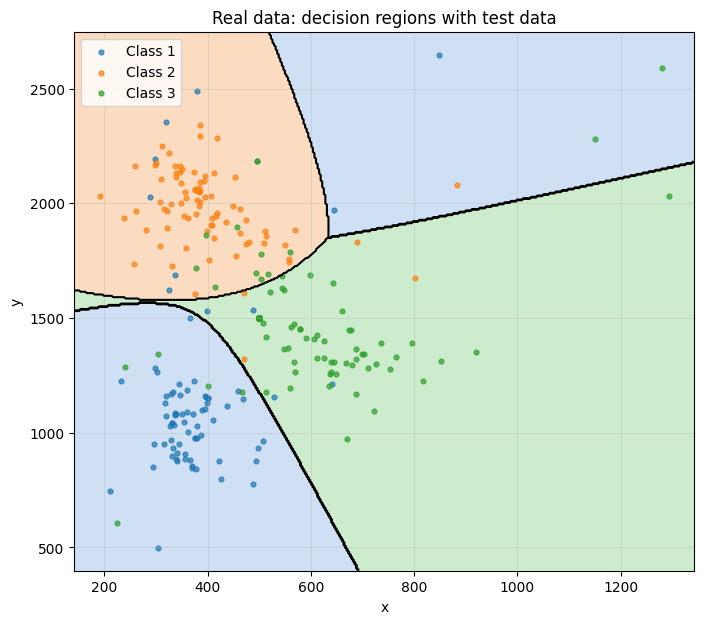

In [34]:
gx = np.linspace(test_X[:, 0].min() - 50,  test_X[:, 0].max() + 50,  400)
gy = np.linspace(test_X[:, 1].min() - 100, test_X[:, 1].max() + 100, 400)
GX, GY = np.meshgrid(gx, gy)
grid = np.column_stack((GX.ravel(), GY.ravel()))

S = np.column_stack([g(grid, *params[c]) for c in (1, 2, 3)])
Z = (np.argmax(S, axis=1) + 1).reshape(GX.shape)

bg = plt.matplotlib.colors.ListedColormap(["#cfe0f5", "#fbdcc0", "#cdeccd"])

plt.figure(figsize=(8, 7))
plt.contourf(GX, GY, Z, levels=[0.5, 1.5, 2.5, 3.5], cmap=bg)
plt.contour(GX, GY, Z, levels=[1.5, 2.5], colors="black", linewidths=1.5)
for c in (1, 2, 3):
    pts = test_X[test_y == c]
    plt.scatter(pts[:, 0], pts[:, 1], s=12, alpha=0.7, color=colors[c], label=f"Class {c}")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Real data: decision regions with test data")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

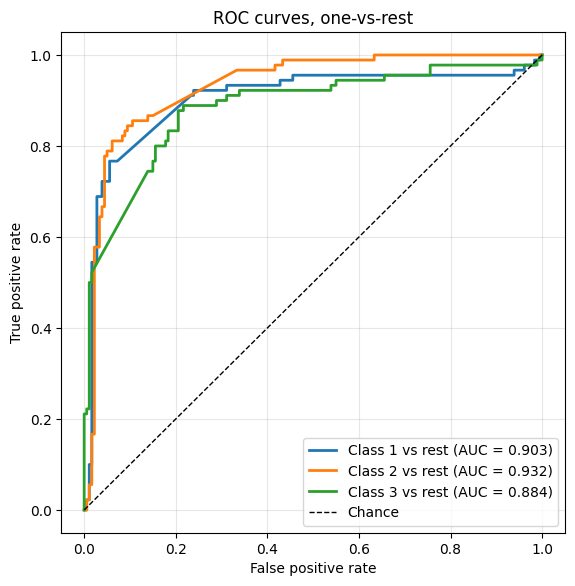

In [35]:
# posterior probabilities from the g values (equal priors)
G_shift = G - np.max(G, axis=1, keepdims=True)
E = np.exp(G_shift)
post = E / np.sum(E, axis=1, keepdims=True)

def roc_points(scores, is_pos):
    thresholds = np.sort(scores)[::-1]       # high to low
    P = np.sum(is_pos)
    N = np.sum(~is_pos)
    tpr = [0.0]
    fpr = [0.0]
    for t in thresholds:
        called_pos = scores >= t
        tpr.append(np.sum(called_pos & is_pos) / P)
        fpr.append(np.sum(called_pos & ~is_pos) / N)
    return np.array(fpr), np.array(tpr)

plt.figure(figsize=(6.5, 6.5))
for k, c in enumerate((1, 2, 3)):
    fpr, tpr = roc_points(post[:, k], test_y == c)
    auc = np.sum((fpr[1:] - fpr[:-1]) * (tpr[1:] + tpr[:-1]) / 2)   # trapezoid area
    plt.plot(fpr, tpr, color=colors[c], lw=2, label=f"Class {c} vs rest (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("ROC curves, one-vs-rest")
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.show()